# Customer Segmentation — Exploratory Data Analysis

This notebook explores the cleaned, feature-engineered customer dataset
(`data/processed/customer_segmentation_clean.csv`, produced by `src/data_processing.py`)
to understand distributions, relationships, and segment-relevant patterns **before**
clustering. Findings here directly informed the feature choices used in
`src/clustering.py`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

df = pd.read_csv("../data/processed/customer_segmentation_clean.csv")
df.shape

(2236, 29)

## 1. Overview

In [2]:
df.head()

,Education,Marital_Status,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,AcceptedCmp2,Complain,Response,Age,Customer_Tenure_Days,Total_Children,Family_Size,Total_Spending,Total_Purchases,Total_Campaigns_Accepted
0,Undergraduate,Single,58138.0,58,635,88,546,172,88,88,...,0,0,1,69,663,0,1,1617,25,1
1,Undergraduate,Single,46344.0,38,11,1,6,2,1,6,...,0,0,0,72,113,2,3,27,6,0
2,Undergraduate,Partnered,71613.0,26,426,49,127,111,21,42,...,0,0,0,61,312,0,2,776,21,0
3,Undergraduate,Partnered,26646.0,26,11,4,20,10,3,5,...,0,0,0,42,139,1,3,53,8,0
4,PhD,Partnered,58293.0,94,173,43,118,46,27,15,...,0,0,0,45,161,1,3,422,19,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2236 entries, 0 to 2235
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Education                 2236 non-null   object 
 1   Marital_Status            2236 non-null   object 
 2   Income                    2236 non-null   float64
 3   Recency                   2236 non-null   int64  
 4   MntWines                  2236 non-null   int64  
 5   MntFruits                 2236 non-null   int64  
 6   MntMeatProducts           2236 non-null   int64  
 7   MntFishProducts           2236 non-null   int64  
 8   MntSweetProducts          2236 non-null   int64  
 9   MntGoldProds              2236 non-null   int64  
 10  NumDealsPurchases         2236 non-null   int64  
 11  NumWebPurchases           2236 non-null   int64  
 12  NumCatalogPurchases       2236 non-null   int64  
 13  NumStorePurchases         2236 non-null   int64  
 14  NumWebVi

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Income,2236.0,51952.614043,21411.466851,1730.0,35502.50,51381.5,68275.75,162397.0
Recency,2236.0,49.116279,28.957284,0.0,24.00,49.0,74.00,99.0
MntWines,2236.0,304.127460,336.591810,0.0,24.00,174.0,504.25,1493.0
MntFruits,2236.0,26.275939,39.724007,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2236.0,166.983453,225.689645,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2236.0,37.536225,54.648562,0.0,3.00,12.0,50.00,259.0
MntSweetProducts,2236.0,27.080501,41.299504,0.0,1.00,8.0,33.00,263.0
MntGoldProds,2236.0,43.983005,52.061568,0.0,9.00,24.0,56.00,362.0
NumDealsPurchases,2236.0,2.326029,1.933032,0.0,1.00,2.0,3.00,15.0
NumWebPurchases,2236.0,4.087657,2.779988,0.0,2.00,4.0,6.00,27.0


## 2. Distributions of key numeric features

Age, Income, and Total_Spending are the three variables most likely to drive
meaningful customer segments — worth understanding their shape before modeling.

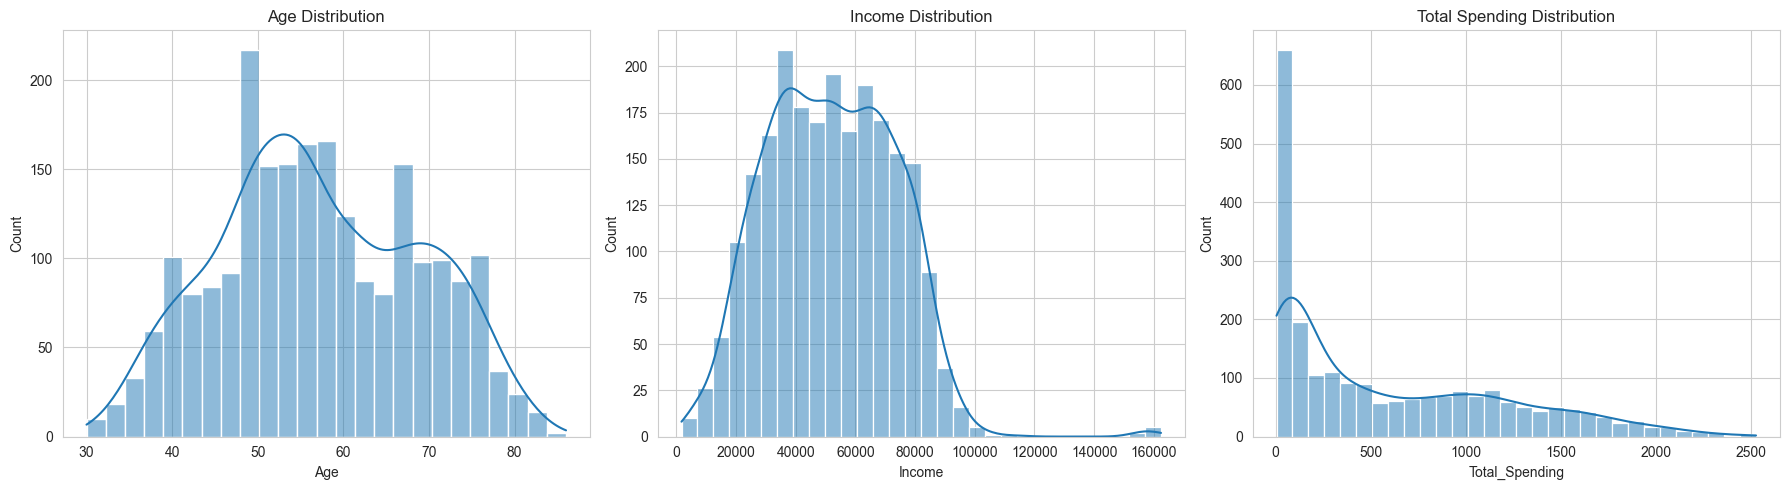

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df["Age"], bins=25, kde=True, ax=axes[0])
axes[0].set_title("Age Distribution")

sns.histplot(df["Income"], bins=30, kde=True, ax=axes[1])
axes[1].set_title("Income Distribution")

sns.histplot(df["Total_Spending"], bins=30, kde=True, ax=axes[2])
axes[2].set_title("Total Spending Distribution")

plt.tight_layout()
plt.show()

**Observation:** Age is roughly centered around the late 40s/50s. Income and
Total_Spending are both **right-skewed** — a minority of customers earn/spend far more
than the median. This is exactly why the clustering pipeline applies a `log1p` transform
to these variables before scaling — without it, K-Means (which is distance-based) would
be disproportionately influenced by a small number of extreme spenders.

## 3. Categorical relationships: Education & Marital Status

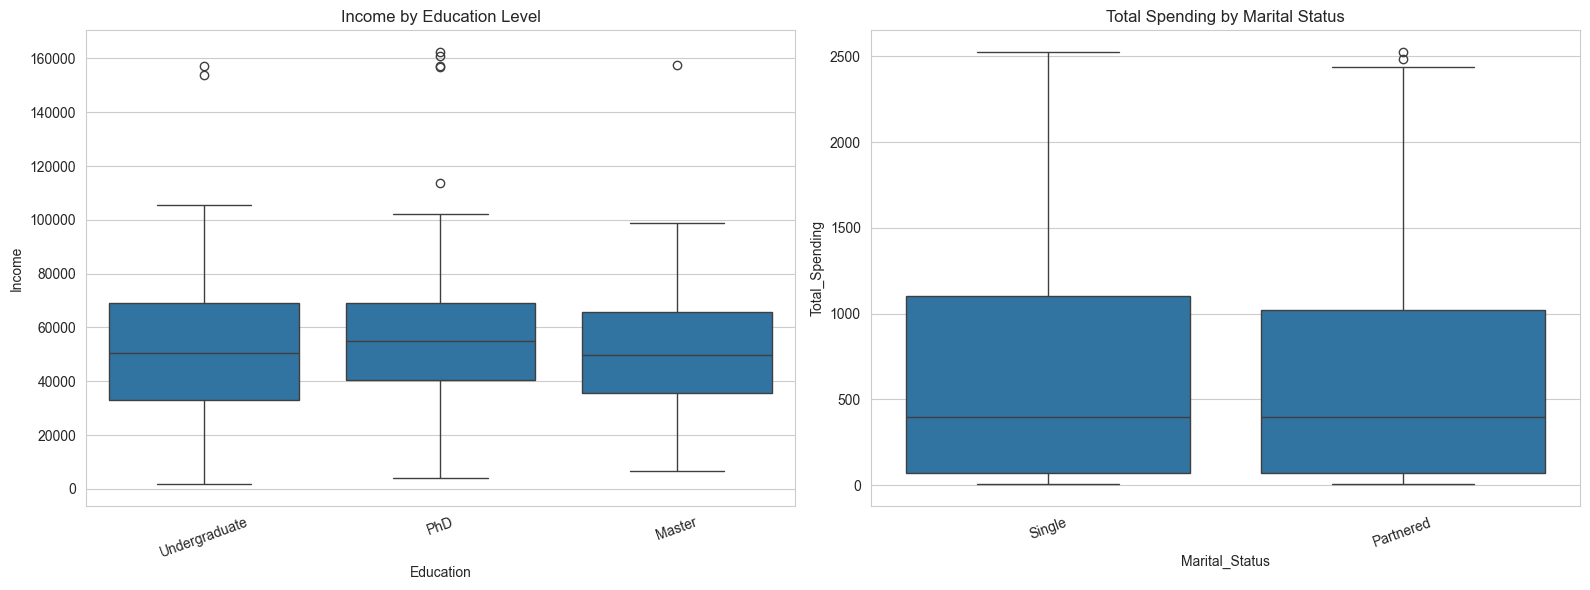

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df, x="Education", y="Income", ax=axes[0])
axes[0].set_title("Income by Education Level")
axes[0].tick_params(axis="x", rotation=20)

sns.boxplot(data=df, x="Marital_Status", y="Total_Spending", ax=axes[1])
axes[1].set_title("Total Spending by Marital Status")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

**Observation:** Education level shows a visible income gradient (PhD/Master
generally higher than Undergraduate). Spending is fairly similar across marital status
groups, with more variance than a strong separating signal — one reason categorical
demographic features ended up contributing less than behavioral features
(spending, purchase counts, campaign response) in the final clustering feature set.

## 4. Correlation between key numeric features

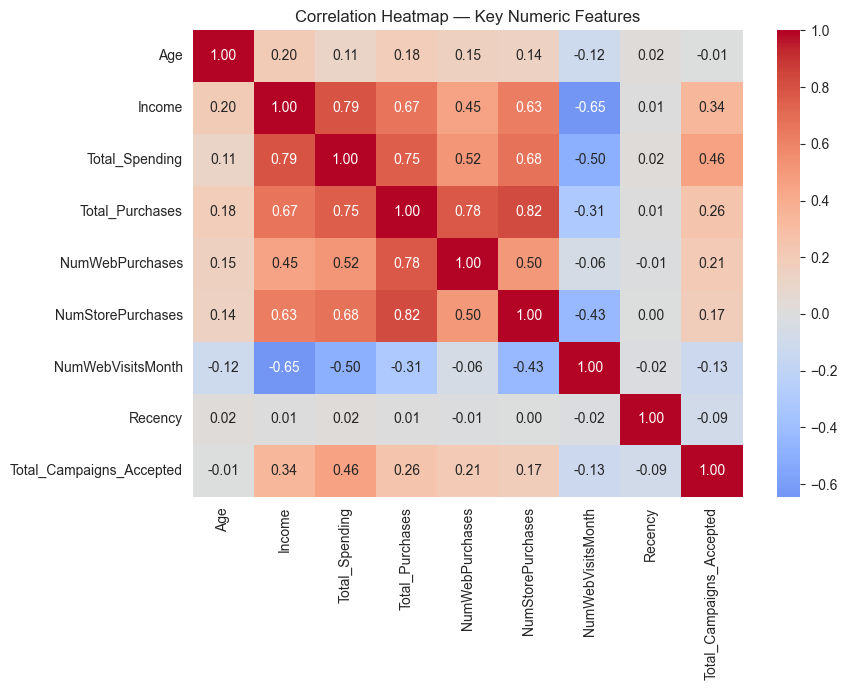

In [7]:
numeric_cols = [
    "Age", "Income", "Total_Spending", "Total_Purchases",
    "NumWebPurchases", "NumStorePurchases", "NumWebVisitsMonth",
    "Recency", "Total_Campaigns_Accepted",
]

corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap — Key Numeric Features")
plt.tight_layout()
plt.show()

**Observation:** `Income` and `Total_Spending` are strongly positively correlated,
as expected. `NumWebVisitsMonth` tends to correlate *negatively* with spending —
customers who browse more online without buying tend to spend less overall, a useful
distinguishing signal. `Recency` shows weak correlation with everything else, meaning it
contributes largely independent information — one reason it earned a place in the
clustering feature set despite not being a "spending" variable.

## 5. Income by Education & Marital Status (pivot table)

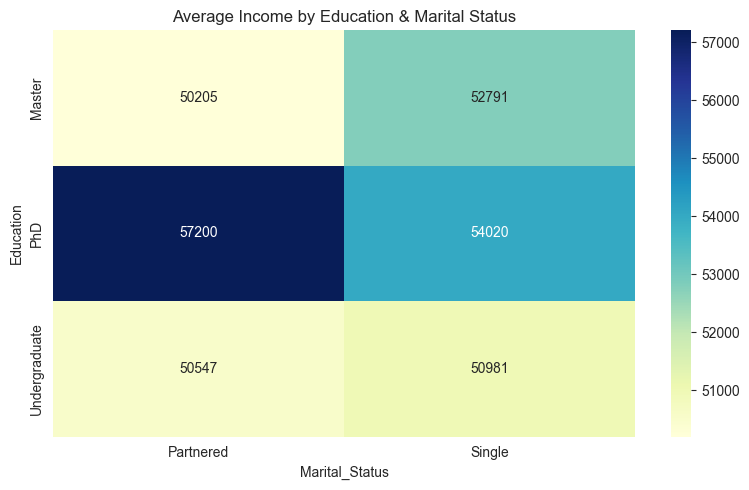

Marital_Status,Partnered,Single
Education,,
Master,50205.0,52791.0
PhD,57200.0,54020.0
Undergraduate,50547.0,50981.0


In [8]:
pivot_income = df.pivot_table(
    values="Income", index="Education", columns="Marital_Status", aggfunc="mean"
).round(0)

plt.figure(figsize=(8, 5))
sns.heatmap(pivot_income, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Average Income by Education & Marital Status")
plt.tight_layout()
plt.show()

pivot_income

## 6. Campaign acceptance patterns

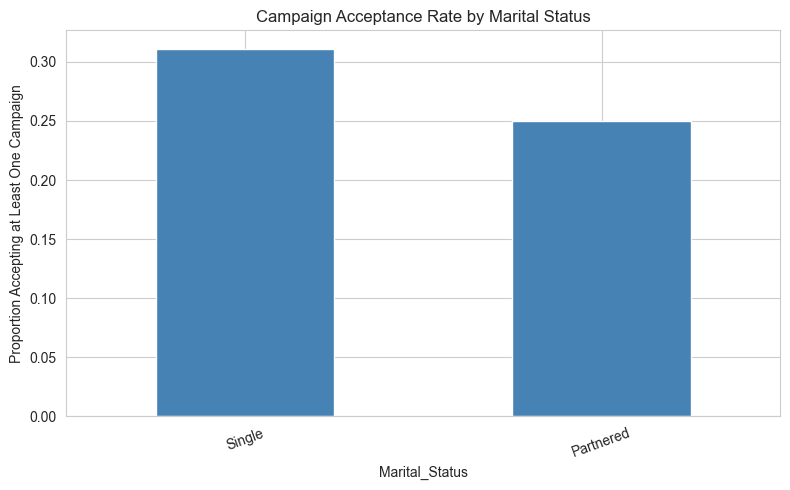

Marital_Status
Single       0.311083
Partnered    0.250347
Name: AcceptedCmpAny, dtype: float64

In [9]:
campaign_cols = [c for c in df.columns if c.startswith("AcceptedCmp")] + ["Response"]
df["AcceptedCmpAny"] = (df[campaign_cols].sum(axis=1) > 0).astype(int)

acceptance_by_marital = df.groupby("Marital_Status")["AcceptedCmpAny"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
acceptance_by_marital.plot(kind="bar", color="steelblue")
plt.title("Campaign Acceptance Rate by Marital Status")
plt.ylabel("Proportion Accepting at Least One Campaign")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

acceptance_by_marital

**Observation:** Campaign acceptance varies noticeably by marital status, but the
much stronger split (confirmed during clustering) is by income/spending tier — the small
group of high-income, high-spending customers accepts campaigns at a dramatically higher
rate than everyone else, which is exactly what became the "VIP segment" (Cluster 1) in
the final clustering results.

## 7. Spending by education level

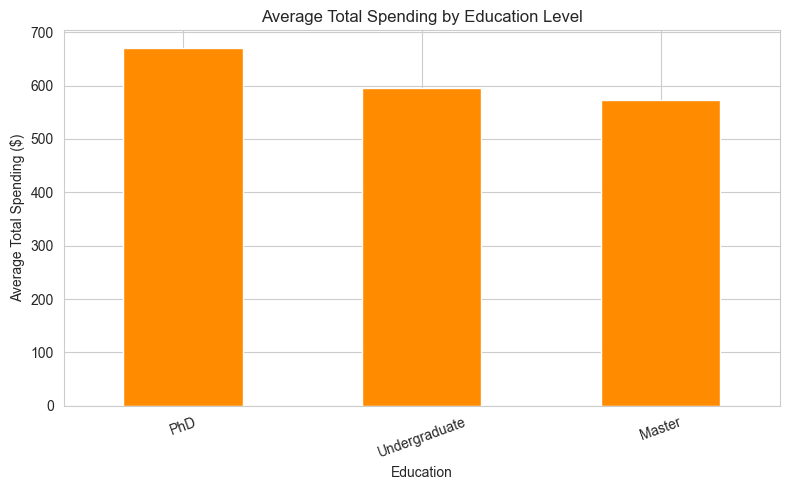

Education
PhD              669.975258
Undergraduate    595.746610
Master           572.796848
Name: Total_Spending, dtype: float64

In [10]:
spending_by_education = df.groupby("Education")["Total_Spending"].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
spending_by_education.plot(kind="bar", color="darkorange")
plt.title("Average Total Spending by Education Level")
plt.ylabel("Average Total Spending ($)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

spending_by_education

## 8. Summary — how this EDA informed clustering

- **Income and Total_Spending are right-skewed** → log-transformed before scaling in the
  clustering pipeline.
- **Extreme values exist in both** → `RobustScaler` (median/IQR-based) was chosen over
  `StandardScaler` for exactly this reason, and empirically improved Silhouette Score.
- **Categorical demographics (Education, Marital_Status) show real but modest
  differences** compared to behavioral features (spending, purchases, campaign
  response) → the final clustering feature set is built from behavioral/numeric
  signals rather than demographic categories.
- **Campaign acceptance is concentrated in a small, high-value group** → this became
  the basis for identifying the distinct VIP segment during clustering, rather than
  something that needed to be engineered in from scratch.

See `src/clustering.py` and `README.md` for the full clustering methodology and
evaluation results that build on these findings.